In [1]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from scdeepsim.plot import compare_umap
from scdeepsim.quality import knn_discriminability, rf_discriminability

In [2]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=2000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']]
muris_10k = muris_10k.copy()
muris_10k.X = muris_10k.X.toarray() # convert to dense matrix 
muris_10k.X
muris_10k.obs

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


,celltype,n_genes,counts
CTCATTATCAGAAATG-1,Spleen,1100,2810.0
227692,Trachea,1369,3472.0
380912,Trachea,1185,2913.0
TCAGCAAGTTCGCGAC-1,Spleen,1564,5421.0
TGTATTCAGGGAGTAA-1,Lung,1226,4809.0
...,...,...,...
ACTGAGTCAGGGTTAG-1,Lung,856,1432.0
TCGAGGCTCTTAGCCC-1,Liver,608,1494.0
CACACTCCACAGGAGT-1,Tongue,2870,12585.0
GTGCAGCCAATCACAC-1,Spleen,961,2408.0


In [ ]:
from scdesigner.simulators import NegBinCopula

nbc = NegBinCopula(mean_formula = "~ celltype")
nbc.fit(muris_10k, max_epochs=300, top_k=100)
nbc_samples = nbc.sample(obs=muris_10k.obs)

Estimating top-k copula covariance: 100%|██████████| 10/10 [00:02<00:00,  4.26it/s]


In [3]:
muris_10k.layers

Layers with keys: 

In [4]:
processed_muris_10k = muris_10k.copy()
sc.pp.normalize_total(processed_muris_10k)
sc.pp.log1p(processed_muris_10k)

In [5]:
muris_10k.obs

,celltype,n_genes,counts
CTCATTATCAGAAATG-1,Spleen,1100,2810.0
227692,Trachea,1369,3472.0
380912,Trachea,1185,2913.0
TCAGCAAGTTCGCGAC-1,Spleen,1564,5421.0
TGTATTCAGGGAGTAA-1,Lung,1226,4809.0
...,...,...,...
ACTGAGTCAGGGTTAG-1,Lung,856,1432.0
TCGAGGCTCTTAGCCC-1,Liver,608,1494.0
CACACTCCACAGGAGT-1,Tongue,2870,12585.0
GTGCAGCCAATCACAC-1,Spleen,961,2408.0


In [ ]:
import scvi

muris_1k = muris_10k[np.random.choice(muris_10k.n_obs, 1000, replace=False)]
muris_1k  = muris_1k.copy()
scvi.model.SCVI.setup_anndata(muris_1k, 
                              categorical_covariate_keys=['celltype'])
scvi_model = scvi.model.SCVI(muris_1k, use_observed_lib_size=False)
scvi_model.train()

IndexError: positional indexers are out-of-bounds

`SCVI.posterior_predictive_sample`:
1. Sample $\hat{z}$ from $p(z|x)$
2. Sample $\hat{x}$ from $p(x|\hat{z})$

In [7]:
ln = scvi_model.get_latent_library_size()
plt.hist(ln)

RuntimeError: The module for this model does not compute the posterior distribution for the library size. Set `give_mean` to False to use the observed library size instead.

In [9]:
scvi_samples = scvi_model.posterior_predictive_sample()

0.7456707967894103 0.6835
Performing UMAP on combined dataset (20000 samples, 2000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[  1.8463573,  -3.1998353],
         [ 17.533669 ,   8.6137705],
         [  9.670658 , -14.6603985],
         ...,
         [ 13.676379 ,   9.720772 ],
         [ 14.368625 ,   8.595114 ],
         [ 13.337172 ,   8.41825  ]], shape=(10000, 2), dtype=float32),
  array([[  1.9663073,  -4.5430827],
         [ 18.289484 ,   8.728333 ],
         [  9.831565 , -15.098935 ],
         ...,
         [ 13.827575 ,   9.563119 ],
         [ 14.723555 ,   8.549079 ],
         [ 12.9359   ,  10.831592 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

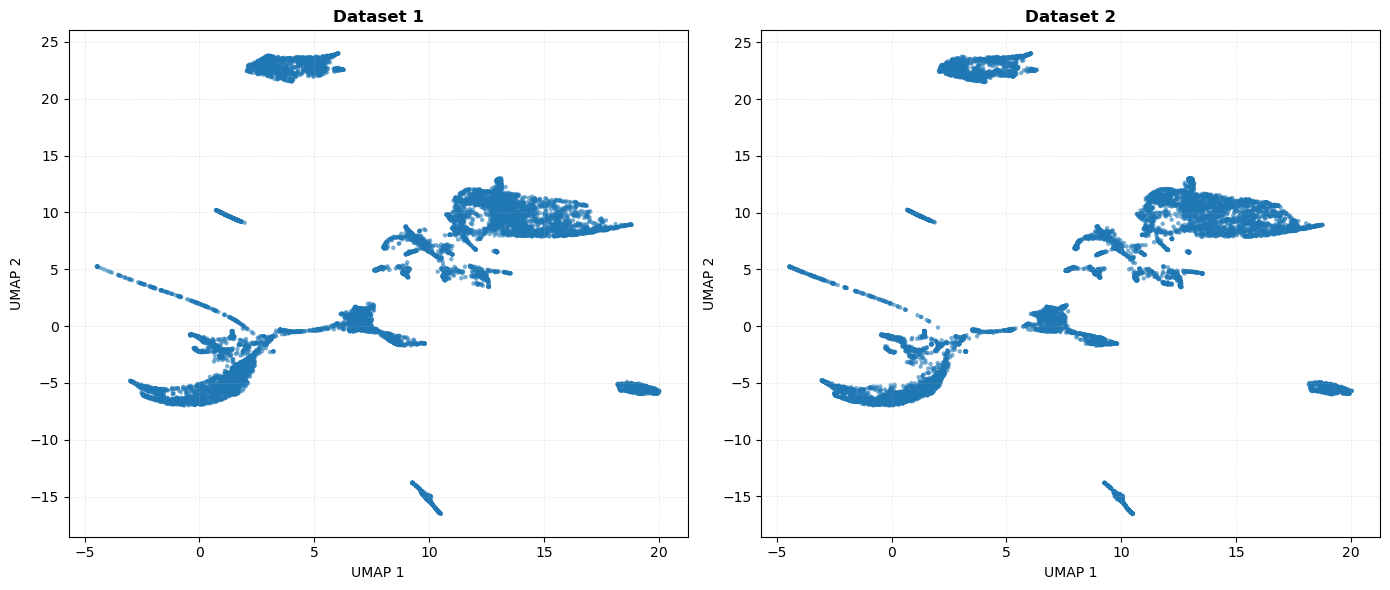

In [17]:
dense_samples = scvi_samples.todense()
auc, acc = knn_discriminability(dense_samples, muris_10k.X)
print(auc, acc)
compare_umap([dense_samples, muris_10k.X])

Standard VAE sampling:
1. Draw $z \sim \mathcal{N}(0, I)$
2. $x = f_{\text{decoder}}(z)$

In [24]:
scvi_model.summary_stats

n_batch: 1
n_cells: 10000
n_extra_categorical_covs: 1
n_extra_continuous_covs: 0
n_labels: 1
n_vars: 2000

In [28]:
muris_10k.obs

,celltype,n_genes,counts,_scvi_batch,_scvi_labels
ATGGGAGGTAAACCTC-1,Spleen,801,1995.0,0,0
226696,Trachea,1818,6016.0,0,0
CCTATTAGTATAAACG-1,Marrow,978,4651.0,0,0
TCAATCTAGGAATGGA-1,Liver,1076,2663.0,0,0
TGCGGGTGTATCAGTC-1,Lung,1523,3502.0,0,0
...,...,...,...,...,...
ACTTACTCACAAGTAA-1,Mammary_Gland,1763,5354.0,0,0
69155,Trachea,1198,3163.0,0,0
TGGTTAGGTTGCGCAC-1,Lung,1232,2155.0,0,0
346273,Trachea,1191,2257.0,0,0


In [ ]:
scvi_model.get_latent

In [39]:
def sample_from_prior(model, n_samples, data):
    device = model.device
    n_latent = model.get_latent_representation().shape[1]
    z = torch.randn(n_samples, n_latent).to(device)

    obs_indices = np.random.choice(len(data), n_samples, replace=True)
    batch_indices = torch.tensor(
        data.obs['_scvi_batch'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    labels = torch.tensor(
        data.obs['_scvi_labels'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    latent_library = model.get_latent_library_size(indices = obs_indices, give_mean=False)
    library = torch.tensor(np.log(latent_library), dtype=torch.float32).to(device)

    model.module.eval()
    with torch.no_grad():
        scvi_prior_samples = model.module.generative(z = z, 
                                                        batch_index = batch_indices, 
                                                        library = library,
                                                        y = labels)
    px = scvi_prior_samples['px']
    simulated_data = px.sample().cpu().numpy()
    return simulated_data

simulated_data = sample_from_prior(scvi_model, 10000, muris_10k)

In [38]:
knn_discriminability(simulated_data, muris_10k.X)

(0.9875740035538207, 0.95375)